## Full S2E simulation demo

This notebook shows how to run a full start-to-end FACET-II simulation

In [ ]:
#Import all the UTILITY functions
import FACET2_S2E as qs
from pmd_beamphysics import ParticleGroup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

filepath = str(Path(os.getcwd()).parent)
#Load a reference configuration
importedDefaultSettings = qs.loadConfig("/setLattice_configs/2024-10-22_oneBunch_baseline3.yml",filepath)


#Initialize tao object; tell it to run IMPACT-T to generate the initial beam

    

csrTF = True
transverseWakes = False



    
tao = qs.initializeTao(
    filePath=filepath,
    inputBeamFilePathSuffix = importedDefaultSettings["inputBeamFilePathSuffix"],
    csrTF = csrTF,
    scratchPath = "/tmp",
    randomizeFileNames = True,
    runQPAD= True,
    setQPADDefaultsFile = "qpad/2025-08-20-QPAD_defaults.yml",
    transverseWakes = transverseWakes,
    #Commands to start and run IMPACT-T. Overwriting some default settings, just to demonstrate
    runImpactTF = True,
    numMacroParticles = int(1e4),
    impactChargepC = 1800,
    impactGridCount = 4
    # These settings give a very low fidelity simulation, but are selected to give a quick demo
)

# Set up lattice
qs.setLattice(tao, **importedDefaultSettings)
# print(importedDefaultSettings)

qs.trackBeam(tao, filepath=filepath, plasmaSIM=True, **importedDefaultSettings)
P = qs.getBeamAtElement(tao, "PENT")


#Figure of LPS at PENT

P2 = qs.getBeamAtElement(tao, "PEXT")

Environment set to:  /sdf/home/c/cropp/FACET2-S2E
-init /sdf/home/c/cropp/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
CSR on
Overwriting lattice with setLattice() defaults
No defaults file provided to setLattice(). Using /sdf/home/c/cropp/FACET2-S2E/setLattice_configs/defaults.yml
Number of macro particles = 10000
Beam created, written to /tmp/beams/activeBeamFile_12440095558002887180.h5, and reinit to tao
Running QPAD Simulation in /tmp/beams/qpad_sim_12440095558002887180
 Terminating simulation...                                                          


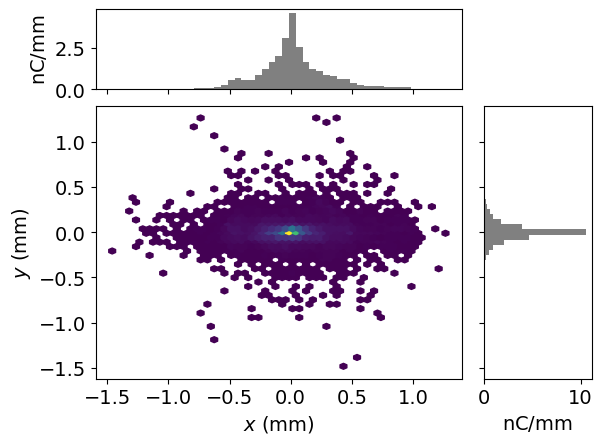

In [3]:
P2.plot("x","y")